# Model Implementation
**Date:** May 20, 2026

## STEP 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

## STEP 2 — Load Processed Dataset

In [2]:
df = pd.read_csv("stock_datasets/RELIANCE_processed.csv")
print(df.head())

         Open        High         Low       Close     Volume  Year  Month  \
0  182.210689  182.734959  179.814022  180.199203  16.443073  2015      3   
1  182.007341  184.008127  179.963758  183.355469  16.763631  2015      3   
2  183.387595  186.650917  182.895423  185.880554  16.042282  2015      3   
3  187.357080  187.603159  182.767042  183.205719  16.449886  2015      3   
4  183.580189  184.275658  181.590101  182.767044  16.157866  2015      3   

   Day  DayOfWeek    Return  ...        MA50  Volatility  Momentum  \
0   16          0 -0.009410  ...  188.356170    0.018170 -2.878067   
1   17          1  0.017515  ...  188.223284    0.018828 -1.583527   
2   18          2  0.013772  ...  188.150956    0.012781 -6.879715   
3   19          3 -0.014390  ...  188.066646    0.012782 -6.783401   
4   20          4 -0.002394  ...  188.143682    0.012788 -6.601486   

         Lag1        Lag2        Lag3     Range       EMA10        RSI  \
0  181.911057  184.842682  183.162903  2.9

## STEP 3 — Check Dataset Info

In [3]:
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Open        2736 non-null   float64
 1   High        2736 non-null   float64
 2   Low         2736 non-null   float64
 3   Close       2736 non-null   float64
 4   Volume      2736 non-null   float64
 5   Year        2736 non-null   int64  
 6   Month       2736 non-null   int64  
 7   Day         2736 non-null   int64  
 8   DayOfWeek   2736 non-null   int64  
 9   Return      2736 non-null   float64
 10  MA10        2736 non-null   float64
 11  MA50        2736 non-null   float64
 12  Volatility  2736 non-null   float64
 13  Momentum    2736 non-null   float64
 14  Lag1        2736 non-null   float64
 15  Lag2        2736 non-null   float64
 16  Lag3        2736 non-null   float64
 17  Range       2736 non-null   float64
 18  EMA10       2736 non-null   float64
 19  RSI         2736 non-null  

## STEP 4 — Separate Features and Target

**Features (X):** Everything except Target.

**Target (y):** Next-day closing price.

In [4]:
X = df.drop(columns=["Target"])
y = df["Target"]

## STEP 5 — Train-Test Split

Chronological 80/20 split — no shuffling to prevent data leakage.

In [5]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test  = X[split_index:]
y_train = y[:split_index]
y_test  = y[split_index:]

## STEP 6 — Verify Split Shapes

In [6]:
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (2188, 20)
X_test : (548, 20)
y_train: (2188,)
y_test : (548,)


## STEP 7 — Apply StandardScaler

The StandardScaler fitted during preprocessing (on training data only) is loaded here and applied to both splits. This ensures all 20 features — including the log-transformed Volume — are on the same scale before training. If the saved scaler is not found (e.g. running this notebook standalone), a fresh scaler is fitted on `X_train` only as a fallback.

In [7]:
scaler_path = 'stock_datasets/scaler_ml.pkl'

if os.path.exists(scaler_path):
    scaler_ml = joblib.load(scaler_path)
    print('Scaler loaded from', scaler_path)
else:
    from sklearn.preprocessing import StandardScaler
    scaler_ml = StandardScaler()
    scaler_ml.fit(X_train)
    joblib.dump(scaler_ml, scaler_path)
    print('Scaler fitted on X_train and saved (fallback).')

X_train_sc = scaler_ml.transform(X_train)
X_test_sc  = scaler_ml.transform(X_test)

print(f'X_train_sc shape : {X_train_sc.shape}')
print(f'X_test_sc  shape : {X_test_sc.shape}')
print(f'Feature means (train, should be ~0): {X_train_sc.mean(axis=0).round(3)}')

Scaler loaded from stock_datasets/scaler_ml.pkl
X_train_sc shape : (2188, 20)
X_test_sc  shape : (548, 20)
Feature means (train, should be ~0): [-0.  0.  0.  0. -0. -0.  0.  0.  0. -0.  0. -0. -0.  0. -0.  0. -0.  0.
 -0. -0.]


## MODEL 1 — Linear Regression

### STEP 8 — Create Linear Regression Model

In [9]:
lr_model = LinearRegression()

### STEP 9 — Train Linear Regression

In [10]:
lr_model.fit(X_train_sc, y_train)
print(lr_model)

LinearRegression()


### STEP 10 — Generate Predictions

In [11]:
y_pred_lr = lr_model.predict(X_test_sc)

### STEP 11 — Check Predictions

In [12]:
print(y_pred_lr[:5])

[1334.67288761 1345.68529755 1442.3906713  1396.31766162 1411.33584308]


### STEP 12 — Feature Coefficients

After scaling, the Linear Regression coefficients are directly comparable. Large positive coefficients push the predicted price up; negative ones pull it down. This reveals which features the model relies on most.

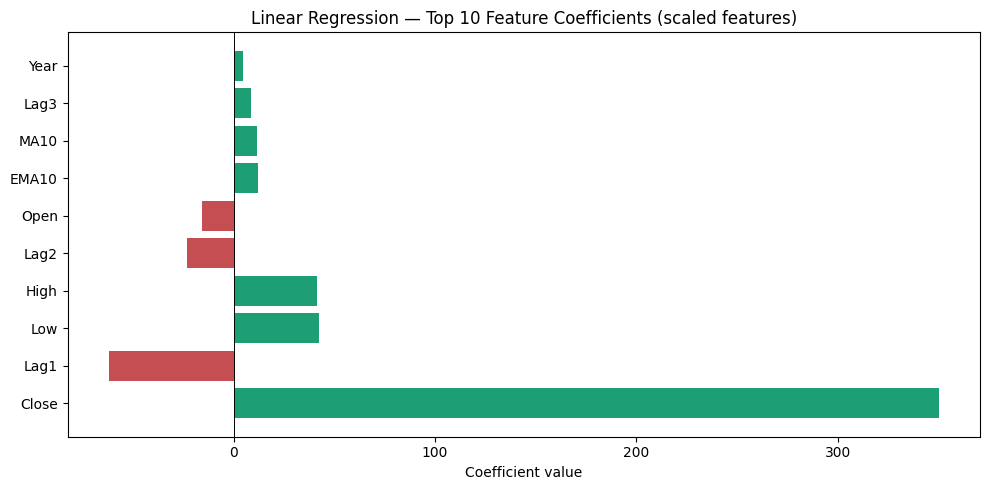

LR coefficient chart saved.


In [13]:
coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False).head(10)

colors = ['#1D9E75' if v > 0 else '#C44E52' for v in coef_df['Coefficient']]

plt.figure(figsize=(10, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.7)
plt.title('Linear Regression — Top 10 Feature Coefficients (scaled features)')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.savefig('stock_datasets/lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('LR coefficient chart saved.')

## MODEL 2 — Random Forest

### STEP 13 — Create Random Forest Model

In [14]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

### STEP 14 — Train Random Forest

In [15]:
rf_model.fit(X_train_sc, y_train)
print(rf_model)

RandomForestRegressor(random_state=42)


### STEP 15 — Generate Predictions

In [16]:
y_pred_rf = rf_model.predict(X_test_sc)

### STEP 16 — Check Predictions

In [17]:
print(y_pred_rf[:5])

[1340.63708008 1342.68367676 1354.15178711 1340.40454468 1343.99744385]


### STEP 17 — Feature Importance

Random Forest exposes `feature_importances_` — the mean decrease in impurity contributed by each feature across all 100 trees. This shows which features the ensemble relies on most.

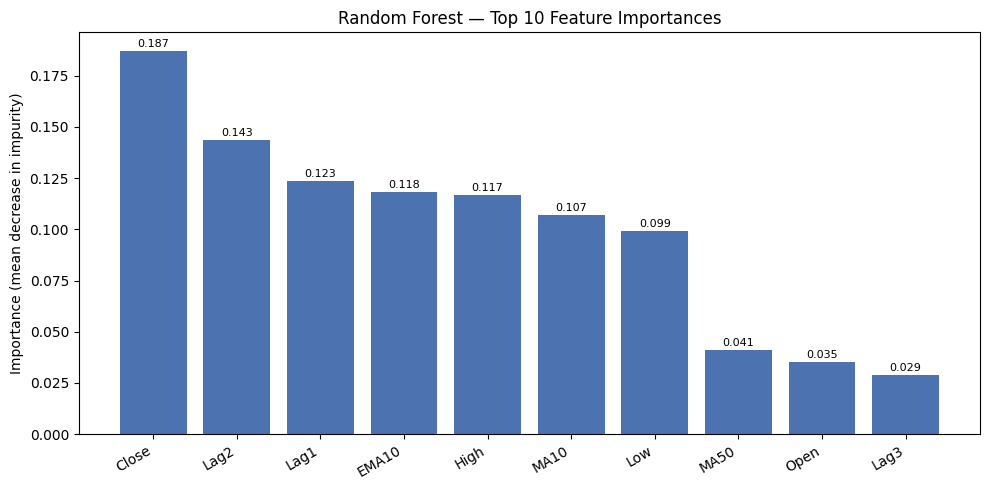

RF feature importance chart saved.


In [18]:
fi_rf = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
bars = plt.bar(fi_rf['Feature'], fi_rf['Importance'], color='#4C72B0')
plt.xticks(rotation=30, ha='right')
plt.title('Random Forest — Top 10 Feature Importances')
plt.ylabel('Importance (mean decrease in impurity)')
for bar, v in zip(bars, fi_rf['Importance']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             v + 0.001, f'{v:.3f}',
             ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('stock_datasets/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('RF feature importance chart saved.')

## MODEL 3 — Gradient Boosting

### STEP 18 — Create Gradient Boosting Model

In [19]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

### STEP 19 — Train Gradient Boosting

In [20]:
gb_model.fit(X_train_sc, y_train)
print(gb_model)

GradientBoostingRegressor(random_state=42)


### STEP 20 — Generate Predictions

In [21]:
y_pred_gb = gb_model.predict(X_test_sc)

### STEP 21 — Check Predictions

In [22]:
print(y_pred_gb[:5])

[1341.35394161 1340.92120458 1350.3819394  1336.09842343 1340.60963556]


### STEP 22 — Feature Importance

Comparing Gradient Boosting importances with Random Forest above shows which features both ensemble methods agree on — those are the most robustly important features in the dataset.

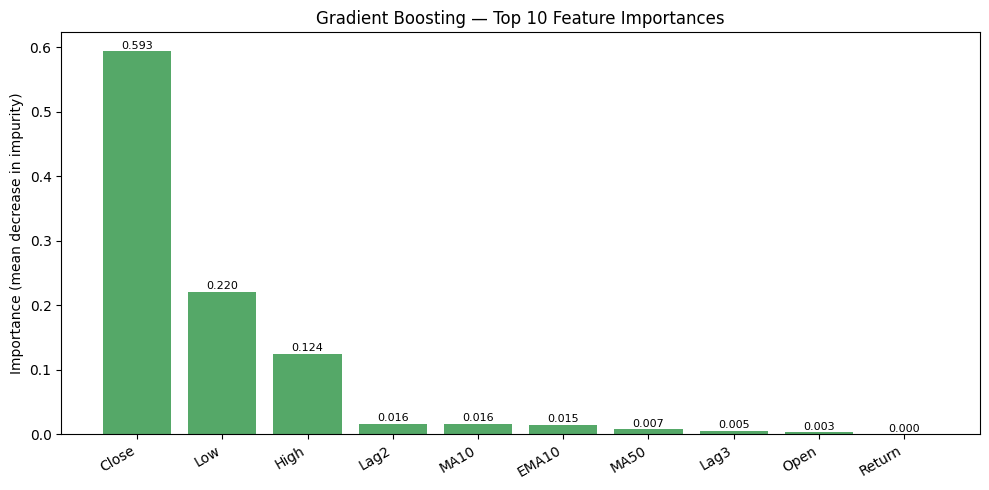

GB feature importance chart saved.


In [23]:
fi_gb = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
bars = plt.bar(fi_gb['Feature'], fi_gb['Importance'], color='#55A868')
plt.xticks(rotation=30, ha='right')
plt.title('Gradient Boosting — Top 10 Feature Importances')
plt.ylabel('Importance (mean decrease in impurity)')
for bar, v in zip(bars, fi_gb['Importance']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             v + 0.001, f'{v:.3f}',
             ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('stock_datasets/gb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('GB feature importance chart saved.')

## STEP 23 — Save Predictions

#### Linear Regression

In [24]:
lr_predictions = pd.DataFrame({
    'Actual':    y_test,
    'Predicted': y_pred_lr
})
lr_predictions.to_csv(
    'stock_datasets/lr_predictions.csv',
    index=False
)

#### Random Forest

In [25]:
rf_predictions = pd.DataFrame({
    'Actual':    y_test,
    'Predicted': y_pred_rf
})
rf_predictions.to_csv(
    'stock_datasets/rf_predictions.csv',
    index=False
)

#### Gradient Boosting

In [26]:
gb_predictions = pd.DataFrame({
    'Actual':    y_test,
    'Predicted': y_pred_gb
})
gb_predictions.to_csv(
    'stock_datasets/gb_predictions.csv',
    index=False
)

## Deep Learning LSTM Model Implementation

### STEP 1 — Import Libraries

In [27]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

2026-05-22 16:03:28.803426: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-22 16:03:28.810539: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-22 16:03:28.865488: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-22 16:03:28.916206: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779446008.955410   46032 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779446008.97

### STEP 2 — Load Processed Arrays

In [28]:
X_train = np.load('stock_datasets/X_train.npy')
X_test  = np.load('stock_datasets/X_test.npy')
y_train = np.load('stock_datasets/y_train.npy')
y_test  = np.load('stock_datasets/y_test.npy')

### STEP 3 — Check Shapes

In [29]:
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (2180, 60, 1)
X_test : (546, 60, 1)
y_train: (2180, 1)
y_test : (546, 1)


### STEP 4 — Build LSTM Model

In [30]:
model = Sequential()

### STEP 5 — Add First LSTM Layer

In [31]:
model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)
model.add(Dropout(0.2))

E0000 00:00:1779446031.338974   46032 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1779446031.346401   46032 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/somdevsheel/anaconda3/envs/stock_env_clean/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### STEP 6 — Add Second LSTM Layer

In [32]:
model.add(
    LSTM(
        units=50,
        return_sequences=False
    )
)
model.add(Dropout(0.2))

### STEP 7 — Add Dense Layers

In [33]:
model.add(Dense(units=25))
model.add(Dense(units=1))

### STEP 8 — Compile Model

In [34]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

### STEP 9 — View Model Summary

In [35]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

### STEP 10 — Define Training Callbacks

Three callbacks are used to improve training:

- **EarlyStopping** (`patience=5`): monitors `val_loss` and stops training when it stops improving, automatically restoring the best weights. This prevents overfitting on a fixed epoch schedule.
- **ModelCheckpoint**: saves the best model weights to disk during training (not just the final epoch) using the modern `.keras` format.
- **ReduceLROnPlateau** (`patience=3, factor=0.5`): halves the learning rate when `val_loss` plateaus, helping the optimiser find better minima.

In [36]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='stock_datasets/lstm_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]
print('Callbacks defined: EarlyStopping | ModelCheckpoint | ReduceLROnPlateau')

Callbacks defined: EarlyStopping | ModelCheckpoint | ReduceLROnPlateau


### STEP 11 — Train LSTM Model

`epochs=50` is the upper limit — EarlyStopping will halt training as soon as `val_loss` stops improving for 5 consecutive epochs.

In [37]:
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)
print(f'\nTraining stopped at epoch {len(history.history["loss"])}')
print(f'Best val_loss : {min(history.history["val_loss"]):.6f}')

Epoch 1/50
67/69 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0433
Epoch 1: val_loss improved from None to 0.00090, saving model to stock_datasets/lstm_best.keras

Epoch 1: finished saving model to stock_datasets/lstm_best.keras
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0153 - val_loss: 8.9935e-04 - learning_rate: 0.0010
Epoch 2/50
68/69 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0021
Epoch 2: val_loss did not improve from 0.00090
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0021 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 3/50
66/69 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0016
Epoch 3: val_loss improved from 0.00090 to 0.00083, saving model to stock_datasets/lstm_best.keras

Epoch 3: finished saving model to stock_datasets/lstm_best.keras
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0016 - val_loss: 8.2657e-04 - learning_rate: 0.0010
Epoch 4/50
67/69 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0015
Epoch 4: val_loss did not improve from 0.00083

Epoch 4: Red

### STEP 12 — Training History Plot

Plotting `loss` vs `val_loss` over epochs is the primary diagnostic for overfitting. If validation loss rises while training loss continues to fall, the model is memorising the training data. The dashed vertical line marks the best epoch selected by EarlyStopping.

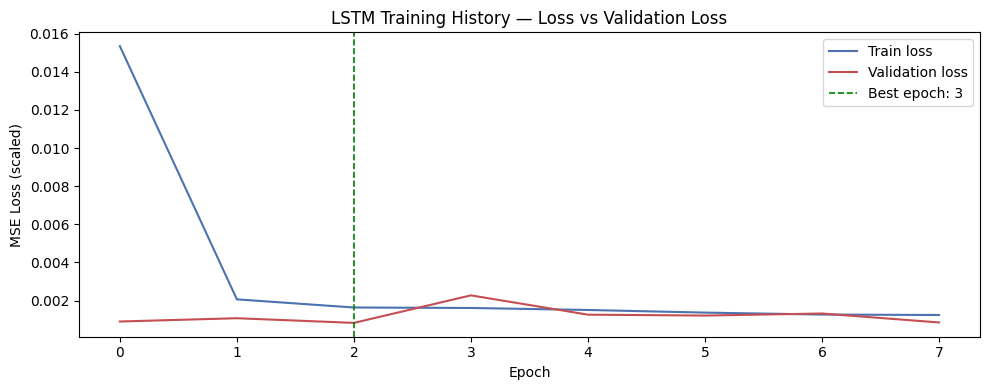

Best val_loss = 0.000827 at epoch 3


In [38]:
best_epoch = int(np.argmin(history.history['val_loss'])) + 1

plt.figure(figsize=(10, 4))
plt.plot(
    history.history['loss'],
    label='Train loss',
    color='#4C72B0',
    linewidth=1.5
)
plt.plot(
    history.history['val_loss'],
    label='Validation loss',
    color='#C44E52',
    linewidth=1.5
)
plt.axvline(
    x=best_epoch - 1,
    color='green',
    linewidth=1.2,
    linestyle='--',
    label=f'Best epoch: {best_epoch}'
)
plt.title('LSTM Training History — Loss vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (scaled)')
plt.legend()
plt.tight_layout()
plt.savefig(
    'stock_datasets/lstm_training_history.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print(f'Best val_loss = {min(history.history["val_loss"]):.6f} at epoch {best_epoch}')

### STEP 13 — Generate Predictions

In [39]:
y_pred_lstm = model.predict(X_test)
print('Prediction shape:', y_pred_lstm.shape)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Prediction shape: (546, 1)


### STEP 14 — Check Predictions

In [40]:
print(y_pred_lstm[:5])

[[0.82458854]
 [0.8284622 ]
 [0.83290344]
 [0.83755374]
 [0.8429816 ]]


### STEP 15 — Save LSTM Model

The model is saved in the modern `.keras` format (Keras native format), which stores the full model — architecture, weights, and optimiser state — in a single file. A reload validation confirms the saved file is intact.

In [41]:
model.save('stock_datasets/lstm_model.keras')
print('Model saved: stock_datasets/lstm_model.keras')

# Reload validation
from tensorflow.keras.models import load_model
loaded_model = load_model('stock_datasets/lstm_model.keras')
test_pred    = loaded_model.predict(X_test[:5], verbose=0)
print(f'Reload validation passed.')
print(f'Sample predictions: {test_pred.flatten().round(4)}')

Model saved: stock_datasets/lstm_model.keras
Reload validation passed.
Sample predictions: [0.8246 0.8285 0.8329 0.8376 0.843 ]


### STEP 16 — Save LSTM Predictions

In [42]:
import pandas as pd

lstm_predictions = pd.DataFrame({
    'Actual':    y_test.flatten(),
    'Predicted': y_pred_lstm.flatten()
})
lstm_predictions.to_csv(
    'stock_datasets/lstm_predictions.csv',
    index=False
)
print('LSTM predictions saved to stock_datasets/lstm_predictions.csv')

LSTM predictions saved to stock_datasets/lstm_predictions.csv
